<span style="float: left;padding: 1.3em">![logo](https://github.com/gw-odw/odw/blob/main/Tutorials/logo.png?raw=1)</span>

#  Gravitational Wave Open Data Workshop

## Tutorial 2.1: Generating Waveforms

This tutorial shows how to numerically obtain the gravitational waveform radiated during a compact binary coalescence, assuming the basic parameters of the binary are known.

We will be using the [PyCBC](https://pycbc.org) library, which provides an easy-to-use Python interface to obtain such waveforms. PyCBC can more generally be used to analyze or simulate gravitational-wave data, find or simulate astrophysical signals from compact binary mergers, and study their parameters. It is one of the tools routinely used by groups within and outside of the LIGO and Virgo collaborations. See [additional examples](https://pycbc.org/pycbc/latest/html/tutorials.html) and [documentation](https://pycbc.org/pycbc/latest/html/index.html).

View this tutorial on [Google Colaboratory](https://colab.research.google.com/github/gw-odw/odw/blob/main/Tutorials/02_Generating_Waveforms/Tuto_2.1_Generating_waveforms.ipynb) or launch [mybinder](https://mybinder.org/v2/gh/gw-odw/odw/HEAD).

In [3]:
# Those 2 lines are just to avoid some harmless warnings when importing packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

## Installation (execute only if running on a cloud platform or if you haven't done the installation already!)

> ⚠️ **Warning**: restart the runtime after running the cell below.
>
> To do so, click "Runtime" in the menu and choose "Restart and run all".
>
> You may see error messages but installation usually works.
> If you experience problems, please [report an issue](https://github.com/gw-odw/odw/issues).

In [4]:
# -- Uncomment following line if running in Google Colab
! pip install -q PyCBC==2.10.0 lalsuite==7.25 cryptography==43.0.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 7.5 MB/s eta 0:00:00


## Initialization

In [5]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

from ipywidgets import interact, interactive, fixed, interact_manual, widgets

## Generate your first waveform!

Here we'll generate the gravitational waveform using one of the available waveform approximants. The waveform can be generated as a time series using [`get_td_waveform()`](https://pycbc.org/pycbc/latest/html/pycbc.waveform.html#pycbc.waveform.waveform.get_td_waveform).

The key parameters are the masses of the binary (given in solar masses), the time between samples (in seconds), the starting gravitational-wave frequency (Hz) and the name of the approximant we'd like to use. A variety of approximants are available that include different physical effects.

For our first example, let's use the `IMRPhenomT` approximant in the time domain ([paper](https://arxiv.org/abs/2012.11923)).
This approximant assumes circular orbits with aligned spins.

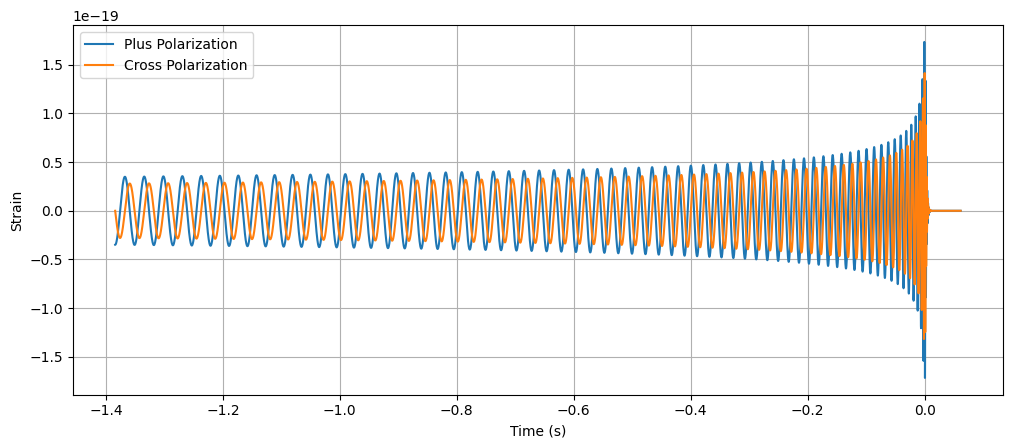

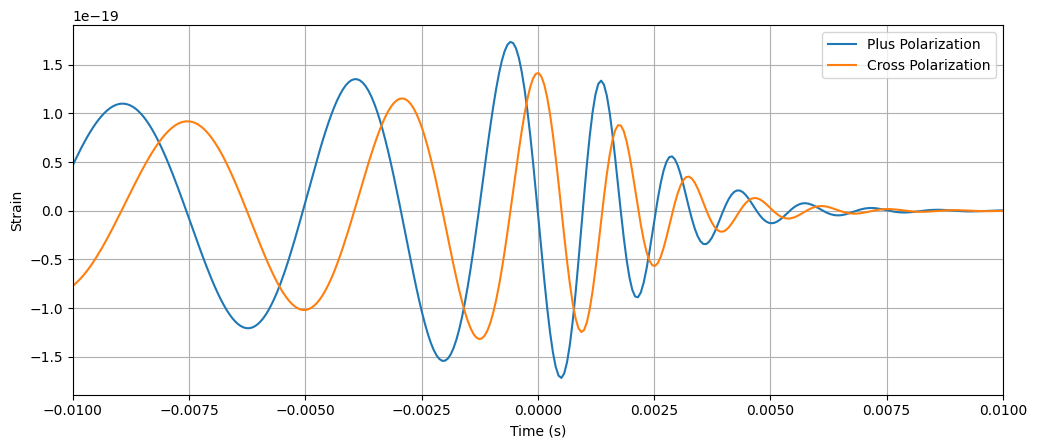

In [6]:
from pycbc.waveform import get_td_waveform

# The outputs of this function are the "plus" and "cross" polarizations
# of the gravitational-wave signal as viewed from the line of sight at
# a given source inclination
# (assumed inclination of pi/3 here, the default is zero inclination if none is provided)
hp, hc = get_td_waveform(approximant="IMRPhenomT",
                         mass1=15,
                         mass2=10,
                         inclination=np.pi/3,
                         delta_t=1.0/16384,
                         f_lower=30)

plt.figure(figsize=plt.figaspect(0.4))
plt.plot(hp.sample_times, hp, label='Plus Polarization')
plt.plot(hp.sample_times, hc, label='Cross Polarization')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.legend()
plt.grid()

# Zoom in near the merger time
plt.figure(figsize=plt.figaspect(0.4))
plt.plot(hp.sample_times, hp, label='Plus Polarization')
plt.plot(hp.sample_times, hc, label='Cross Polarization')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.xlim(-.01, .01)
plt.legend()
plt.grid()

Note that here we have aligned spins, so the orbital plane of the binary does not precess (i.e. the individual black holes spins are aligned with the orbital angular momentum). We also assume zero eccentricity. In the zoom-in plot, we can see the merger itself and the ringdown that follows.

There are many other approximants available, with different methodologies employed and physical effects modelled.
A full review of the models is outside the scope of this tutorial.
You can get a list of all the time-domain models with `td_approximants()`.

In [7]:
# We can list the waveforms available for get_td_waveform
from pycbc.waveform import td_approximants

# List of td approximants that are available
print('Time domain waveforms: ', td_approximants())

Time domain waveforms:  ['TaylorT1', 'TaylorT2', 'TaylorT3', 'SpinTaylorT1', 'SpinTaylorT4', 'SpinTaylorT5', 'PhenSpinTaylor', 'PhenSpinTaylorRD', 'EOBNRv2', 'EOBNRv2HM', 'TEOBResum_ROM', 'SEOBNRv1', 'SEOBNRv2', 'SEOBNRv2_opt', 'SEOBNRv3', 'SEOBNRv3_pert', 'SEOBNRv3_opt', 'SEOBNRv3_opt_rk4', 'SEOBNRv4', 'SEOBNRv4_opt', 'SEOBNRv4P', 'SEOBNRv4PHM', 'SEOBNRv2T', 'SEOBNRv4T', 'SEOBNRv4_ROM_NRTidalv2', 'SEOBNRv4_ROM_NRTidalv2_NSBH', 'HGimri', 'IMRPhenomA', 'IMRPhenomB', 'IMRPhenomC', 'IMRPhenomD', 'IMRPhenomD_NRTidalv2', 'IMRPhenomNSBH', 'IMRPhenomHM', 'IMRPhenomPv2', 'IMRPhenomPv2_NRTidal', 'IMRPhenomPv2_NRTidalv2', 'TaylorEt', 'TaylorT4', 'EccentricTD', 'SpinDominatedWf', 'NR_hdf5', 'NRSur7dq2', 'NRSur7dq4', 'SEOBNRv4HM', 'NRHybSur3dq8', 'IMRPhenomXAS', 'IMRPhenomXHM', 'IMRPhenomPv3', 'IMRPhenomPv3HM', 'IMRPhenomXP', 'IMRPhenomXPHM', 'TEOBResumS', 'IMRPhenomT', 'IMRPhenomTHM', 'IMRPhenomTP', 'IMRPhenomTPHM', 'SEOBNRv4HM_PA', 'pSEOBNRv4HM_PA', 'IMRPhenomXAS_NRTidalv2', 'IMRPhenomXP_NRTidal

There are some additional examples using this interface [here](https://pycbc.org/pycbc/latest/html/waveform.html).

## Waveforms in the frequency domain

We can also generate waveforms in the frequency domain (or Fourier domain) using the function `get_fd_waveform()`.
We will talk in depth about the Fourier domain in the next tutorials.

We will use the `IMRPhenomXAS` approximant in the Fourier domain ([paper](https://arxiv.org/abs/2001.11412)). As `IMRPhenomT`, it assumes circular orbits with aligned spins.

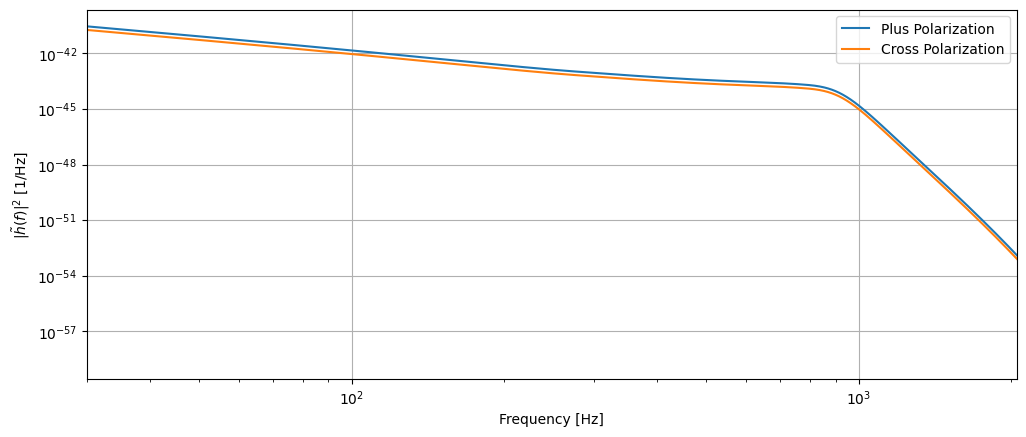

In [8]:
from pycbc.waveform import get_fd_waveform

hp, hc = get_fd_waveform(approximant="IMRPhenomXAS",
                         mass1=10,
                         mass2=10,
                         f_lower=30,
                         inclination=np.pi/3,
                         delta_f=1./8)

plt.figure(figsize=plt.figaspect(0.4))

# We will plot the norm of the Fourier components of the signal polarizations.
plt.loglog(hp.sample_frequencies, hp.squared_norm(), label='Plus Polarization')
plt.loglog(hp.sample_frequencies, hc.squared_norm(), label='Cross Polarization')
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'$|\tilde{h}(f)|^2$ [1/Hz]')
plt.xlim([30,2048])
plt.legend()
plt.grid()

As in the time-domain, there exists many models based on different assumptions.

In [9]:
from pycbc.waveform import fd_approximants

# List of fd approximants that are currently available
print('Frequency domain waveforms: ', fd_approximants())

Frequency domain waveforms:  ['EccentricFD', 'TaylorF2', 'TaylorF2Ecc', 'TaylorF2NLTides', 'TaylorF2RedSpin', 'TaylorF2RedSpinTidal', 'SpinTaylorF2', 'EOBNRv2_ROM', 'EOBNRv2HM_ROM', 'SEOBNRv1_ROM_EffectiveSpin', 'SEOBNRv1_ROM_DoubleSpin', 'SEOBNRv2_ROM_EffectiveSpin', 'SEOBNRv2_ROM_DoubleSpin', 'SEOBNRv2_ROM_DoubleSpin_HI', 'Lackey_Tidal_2013_SEOBNRv2_ROM', 'SEOBNRv4_ROM', 'SEOBNRv4HM_ROM', 'SEOBNRv4_ROM_NRTidal', 'SEOBNRv4_ROM_NRTidalv2', 'SEOBNRv4_ROM_NRTidalv2_NSBH', 'SEOBNRv4T_surrogate', 'IMRPhenomA', 'IMRPhenomB', 'IMRPhenomC', 'IMRPhenomD', 'IMRPhenomD_NRTidal', 'IMRPhenomD_NRTidalv2', 'IMRPhenomNSBH', 'IMRPhenomHM', 'IMRPhenomP', 'IMRPhenomPv2', 'IMRPhenomPv2_NRTidal', 'IMRPhenomPv2_NRTidalv2', 'SpinTaylorT4Fourier', 'SpinTaylorT5Fourier', 'NRSur4d2s', 'IMRPhenomXAS', 'IMRPhenomXHM', 'IMRPhenomPv3', 'IMRPhenomPv3HM', 'IMRPhenomXP', 'IMRPhenomXPHM', 'SEOBNRv5_ROM', 'IMRPhenomXAS_NRTidalv2', 'IMRPhenomXP_NRTidalv2', 'IMRPhenomXO4a', 'ExternalPython', 'SEOBNRv5HM_ROM', 'IMRPhenomX

## Time-domain waveforms from Fourier-domain approximants

The function `get_td_waveform()` also allows us to use a Fourier-domain approximant. Under the hood, the waveform is first generated in the Fourier domain before being inverse-Fourier transformed back to the time domain, with appropriate conditioning. This is why the amplitude is smoothly tapered at the beginning. We will discuss more on Fourier transforms and conditioning in another tutorial.

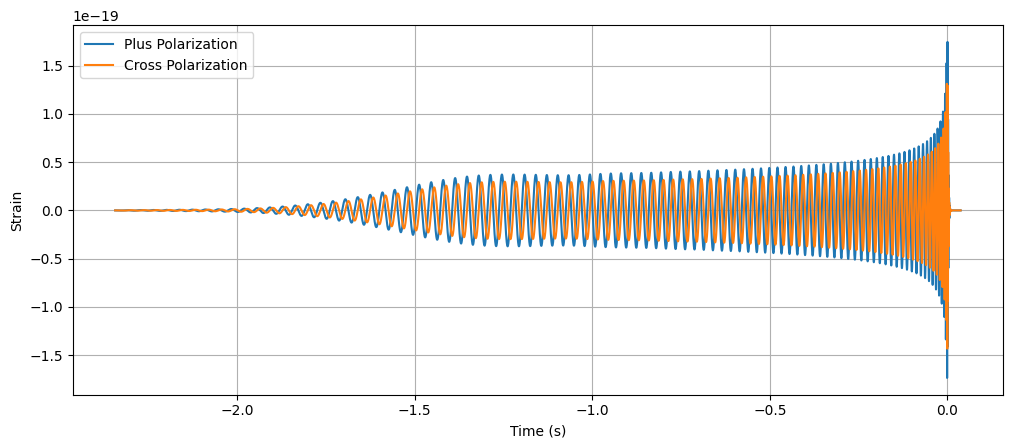

In [10]:
# The outputs of this function are the "plus" and "cross" polarizations
# of the gravitational-wave signal as viewed from the line of sight at
# a given source inclination
# (assumed inclination of pi/3 here, the default is zero inclination if none is provided)
hp, hc = get_td_waveform(approximant="IMRPhenomXAS",
                         mass1=15,
                         mass2=10,
                         inclination=np.pi/3,
                         delta_t=1.0/16384,
                         f_lower=30)

plt.figure(figsize=plt.figaspect(0.4))
plt.plot(hp.sample_times, hp, label='Plus Polarization')
plt.plot(hp.sample_times, hc, label='Cross Polarization')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.legend()
plt.grid()

## Playing with the physical parameters

In order to acquire a qualitative sense of the effect of the most important physical parameters on the waveforms, in the cell below we continuously vary the following parameters:
- the total mass $M=m_1+m_2$ in solar masses. All masses are the 'redshifted' or 'detector-frame' masses, instead of the source-frame masses: $M = (1+z)*M_{\rm source}$; these redshifted masses are the ones that the detector actually observes. We recall also that for binary black holes (vacuum GR), there is a universality relation: rescaling all times to $t/M$, frequencies to $f*M$ and strain to $Dh/M$, where $M$ is the total mass and $D$ is the luminosity distance, BBH waveforms become universal.
- the mass ratio $q = m_2/ m_1 < 1$
- the z-component of the dimensionless spin of body 1, $\chi_1$ (we set all other spin components to 0)
- the luminosity distance to the source $D$, in Mpc; the amplitude of the observed signal taking into account the cosmological expansion is $\propto 1/D$.
- the inclination angle, in radians

For now we use `IMRPhenomT`, which allows for spins aligned with the orbital angular momentum, but does not contain higher harmonics, does not allow for spin precession or eccentricity.

All these waveforms are plotted in the same time interval, and have the same starting frequency at 30Hz.

⚠️ The cell below uses interactive plot which is not displayed correctly on GitHub but works well on Colab or when running locally.

In [11]:
def plot_waveform(M, q, chi1, dist, inc):
    mass1 = M * 1/(1+q)
    mass2 = M * q/(1+q)
    hp, hc = get_td_waveform(approximant="IMRPhenomT",
                         mass1=mass1,
                         mass2=mass2,
                         spin1z=chi1,
                         inclination=inc,
                         distance=dist,
                         delta_t=1.0/2048,
                         f_lower=30)
    fig, ax = plt.subplots(1,1, figsize=[16,4])
    ax.plot(hp.sample_times, hp, label='hp', color='C0')
    ax.plot(hc.sample_times, hc, label='hc', color='C1')
    ax.set_xlim(-1., 0.2)
    ax.set_ylim(-5e-21, 5e-21)
    ax.legend(loc='upper right')
    ax.set_xlabel('t (s)')
    ax.grid()

interact(
    plot_waveform,
    M = widgets.FloatSlider(value=30, min=1, max=100, step=1, description='M'),
    q = widgets.FloatSlider(value=0.8, min=0.05, max=1, step=0.01, description='q'),
    chi1 = widgets.FloatSlider(value=0., min=-1., max=1., step=0.01, description='chi1'),
    dist = widgets.FloatSlider(value=100, min=40, max=400, step=5, description='Dist.'),
    inc = widgets.FloatSlider(value=np.pi/3, min=0., max=np.pi, step=0.02, description='Inc.')
)

interactive(children=(FloatSlider(value=30.0, description='M', min=1.0, step=1.0), FloatSlider(value=0.8, desc…

<function __main__.plot_waveform(M, q, chi1, dist, inc)>

Take some time get a feeling of the effect of some parameters in particular the mass and the distance.

## Going further

If you have time, you might have a look at the `Extracurricular_topics` notebook in this folder.

## Quiz Questions

We will plot the waveforms associated to some real events.
Look up the [GWTC-1](https://gwosc.org/GWTC-1/) catalog page to obtain the estimated masses and distance for these events.

### Question 1

Generate and plot the time-domain waveform associated to the binary neutron star merger GW170817. How much time does the signal last using a lower frequency of 30 Hz?

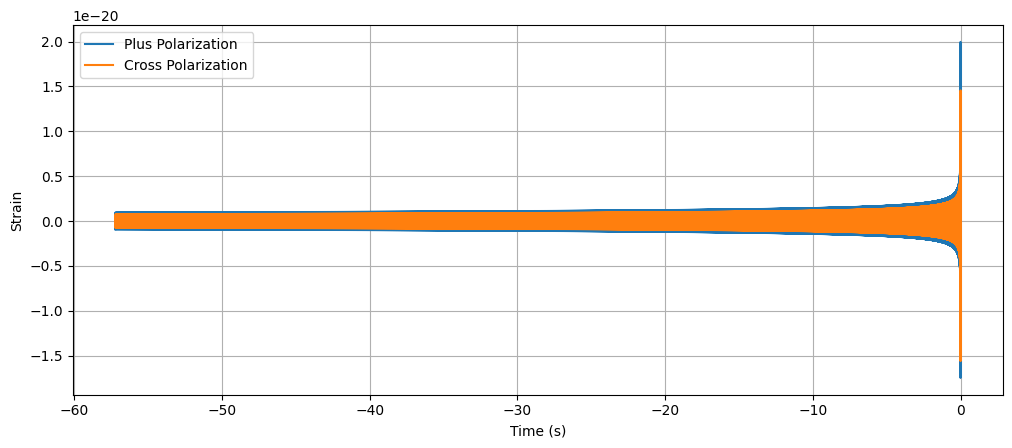

In [12]:
from pycbc.waveform import get_td_waveform

# The outputs of this function are the "plus" and "cross" polarizations
# of the gravitational-wave signal as viewed from the line of sight at
# a given source inclination
# (assumed inclination of pi/3 here, the default is zero inclination if none is provided)
hp, hc = get_td_waveform(approximant="IMRPhenomT",
                         mass1=1.46,
                         mass2=1.27,
                         inclination=np.pi/3,
                         delta_t=1.0/16384,
                         f_lower=30)

plt.figure(figsize=plt.figaspect(0.4))
plt.plot(hp.sample_times, hp, label='Plus Polarization')
plt.plot(hp.sample_times, hc, label='Cross Polarization')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.legend()
plt.grid()

### Question 2

Same question for the binary black hole merger GW150914.

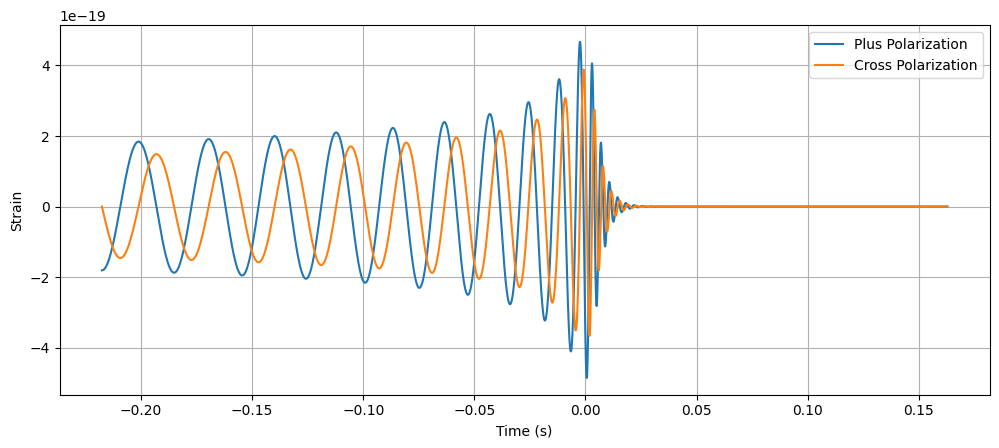

In [13]:
from pycbc.waveform import get_td_waveform

# The outputs of this function are the "plus" and "cross" polarizations
# of the gravitational-wave signal as viewed from the line of sight at
# a given source inclination
# (assumed inclination of pi/3 here, the default is zero inclination if none is provided)
hp, hc = get_td_waveform(approximant="IMRPhenomT",
                         mass1=35.6,
                         mass2=30.6,
                         inclination=np.pi/3,
                         delta_t=1.0/16384,
                         f_lower=30)

plt.figure(figsize=plt.figaspect(0.4))
plt.plot(hp.sample_times, hp, label='Plus Polarization')
plt.plot(hp.sample_times, hc, label='Cross Polarization')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.legend()
plt.grid()